<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/Colebank_100K_Folder/VanillaCNN_Standardized_cleaner_100K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


Using device: cuda
Beginning execution pipeline...
Data files loaded successfully.
Class balance:
  class 0: 477 samples (47.7 %)
  class 1: 523 samples (52.3 %)

Split sizes -> train: 720, val: 180, test: 100
Test set indices from 1K data: [477 837 302 405 333 332 886 730 775 741 601 732 195 112 796 486 827 977
 181 890 800 150 403 972 597 463  38 661 806 535 206 537 298 933 891 746
 742  56 419 936 636  25   6 327 522 215 276 196  50 624  18 367 131 764
 924 629 586 638 783 471 600 685 118 482 965 409 319 673 184 849 331 285
  47 978 465 454 528 826 502 224 666 993 557 544 408 999 348 123 113 714
 404 261 375 381 177 277 724 704 887 504]
Training model...

===== Individual Test Sample Inference Profiles =====
Sample 000 (DF Index: 477) | True: 1 | Pred: 1 | Confidence: 0.5811 | Uncertainty (Std): 0.0000
Sample 001 (DF Index: 837) | True: 1 | Pred: 1 | Confidence: 0.9970 | Uncertainty (Std): 0.0000
Sample 002 (DF Index: 302) | True: 1 | Pred: 0 | Confidence: 0.5315 | Uncertainty (Std)

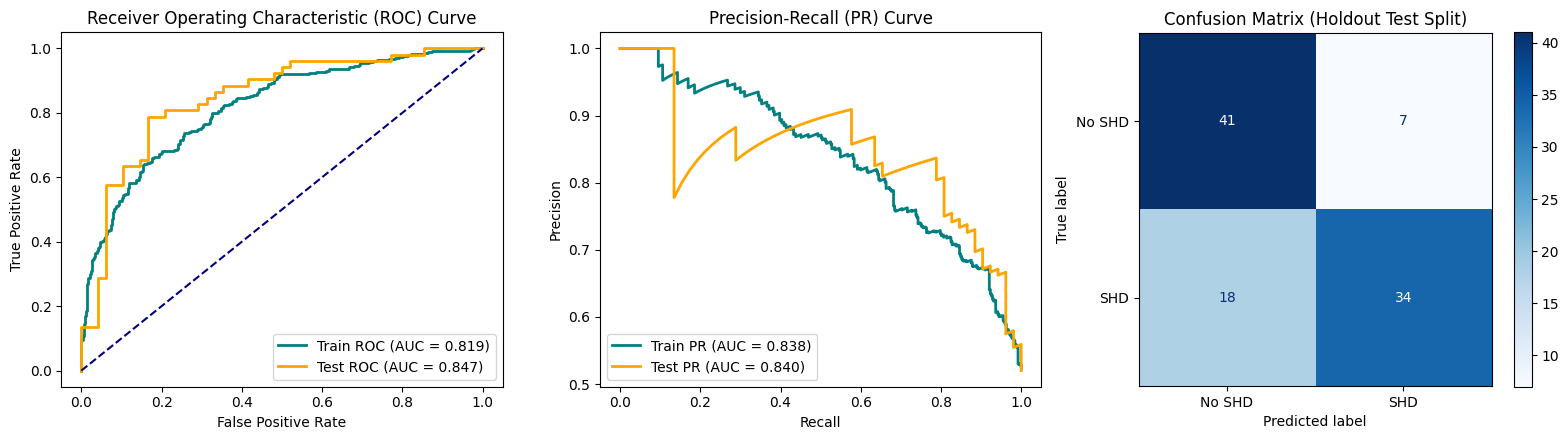

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
    auc,
    ConfusionMatrixDisplay,
)

# ══════════════════════════════════════════════════════════════════════
# 0. CONFIGURATION, REPRODUCIBILITY, DEVICE
# ══════════════════════════════════════════════════════════════════════
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N_SAMPLES = 1000
ECG_PATH = "ECG_waveforms_1K.npy"
ECHO_PATH = "EchoNext_EchoData_5K.csv"
LABEL_COL = "shd_moderate_or_greater_flag"

ECG_SAMPLING_RATE_HZ = 250
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# Splitting structure mapped to exactly match 72% / 18% / 10% partitions
TEST_SIZE = 0.10
VAL_SIZE_OF_REMAINDER = 0.20

EPOCHS = 60
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-2
SCHEDULER_T0 = 20
SCHEDULER_T_MULT = 1
SCHEDULER_ETA_MIN = 1e-5
TRAIN_BATCH_SIZE = 32
VAL_BATCH_SIZE = 128
TEST_BATCH_SIZE = 128


# ══════════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════════
def load_raw_data(ecg_path=ECG_PATH, echo_path=ECHO_PATH, n_samples=N_SAMPLES,
                   max_retries=5, retry_delay=5):
    for attempt in range(max_retries):
        try:
            if not os.path.exists(ecg_path) or not os.path.exists(echo_path):
                raise FileNotFoundError("Required data files not found.")
            ecg_waveforms = np.load(ecg_path)[:n_samples]
            echo_df = pd.read_csv(echo_path).iloc[:n_samples].reset_index(drop=True)
            print("Data files loaded successfully.")
            return ecg_waveforms, echo_df
        except Exception as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed: {e}. Retrying...")
            time.sleep(retry_delay)
    raise RuntimeError("Failed to load required data files after multiple retries.")


# ══════════════════════════════════════════════════════════════════════
# 2. ECG WAVEFORM FILTERING
# ══════════════════════════════════════════════════════════════════════
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=-1)
    return filtered.astype(np.float32)


# ══════════════════════════════════════════════════════════════════════
# 3. PYTORCH DATA STRUCTURING
# ══════════════════════════════════════════════════════════════════════
def make_loader(X_ts, y, idx, batch_size, shuffle):
    X_ts_t = torch.tensor(X_ts[idx], dtype=torch.float32)
    y_t = torch.tensor(y[idx], dtype=torch.long)
    dataset = TensorDataset(X_ts_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


# ══════════════════════════════════════════════════════════════════════
# 4. MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════
class ECGHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()
        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool1d(250),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.AdaptiveAvgPool1d(25),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, num_classes),
        )

    def forward(self, ts_input):
        ts_emb = self.ts_features(ts_input)
        return self.classifier(ts_emb)


# ══════════════════════════════════════════════════════════════════════
# 5. TRAINING ROUTINE
# ══════════════════════════════════════════════════════════════════════
def train_classifier(model, train_loader, val_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=SCHEDULER_T0, T_mult=SCHEDULER_T_MULT, eta_min=SCHEDULER_ETA_MIN
    )

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            X_batch = X_batch + 0.05 * torch.randn_like(X_batch)
            X_batch = X_batch * (0.8 + 0.4 * torch.rand(1, device=device))

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        # Dedicated Evaluation Output Step matching Early Fusion Model logs
        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_val_b, y_val_b in val_loader:
                X_val_b, y_val_b = X_val_b.to(device), y_val_b.to(device)
                logits = model(X_val_b)
                val_loss += criterion(logits, y_val_b).item() * X_val_b.shape[0]
                val_total += X_val_b.shape[0]

        epoch_val_loss = val_loss / val_total
        print(f"Epoch {epoch+1:02d} | Dedicated Validation Loss: {epoch_val_loss:.6f}")
        scheduler.step()

    return model


# ══════════════════════════════════════════════════════════════════════
# 6. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ══════════════════════════════════════════════════════════════════════
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece


def get_predictions_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction="sum")

    with torch.no_grad():
        for X_ts_b, y_b in loader:
            X_ts_b = X_ts_b.to(device)
            logits = model(X_ts_b)
            probs = torch.softmax(logits, dim=-1)

            all_nll += criterion(logits, y_b.to(device)).item()
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_labels), all_nll / len(loader.dataset)


def generate_and_display_comparative_metrics(model, train_loader, test_loader):
    train_probs, train_labels, train_nll = get_predictions_and_labels(model, train_loader)
    test_probs, test_labels, test_nll = get_predictions_and_labels(model, test_loader)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (
            calculate_calibration_error(train_probs, train_labels),
            calculate_calibration_error(test_probs, test_labels),
        ),
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()
    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(train_fpr, train_tpr, color="teal", lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color="orange", lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color="navy", linestyle="--")
    ax[0].set_xlabel("False Positive Rate")
    ax[0].set_ylabel("True Positive Rate")
    ax[0].set_title("Receiver Operating Characteristic (ROC) Curve")
    ax[0].legend(loc="lower right")

    ax[1].plot(train_recall, train_precision, color="teal", lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color="orange", lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    ax[1].set_title("Precision-Recall (PR) Curve")
    ax[1].legend(loc="lower left")

    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(
        ax=ax[2], cmap="Blues", values_format="d"
    )
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════
# 7. EXECUTION PIPELINE
# ══════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    from sklearn.model_selection import train_test_split

    ecg_waveforms, echo_df = load_raw_data()
    y_all = echo_df[LABEL_COL].to_numpy()

    unique, counts = np.unique(y_all, return_counts=True)
    print("Class balance:")
    for cls, cnt in zip(unique.tolist(), counts.tolist()):
        print(f"  class {cls}: {cnt} samples ({cnt / len(y_all) * 100:.1f} %)")

    X_ts_raw = np.swapaxes(ecg_waveforms, 1, 2)
    X_ts_filtered = bandpass_filter_ecg(X_ts_raw)

    all_idx = np.arange(N_SAMPLES)
    trainval_idx, test_idx = train_test_split(
        all_idx, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_all
    )
    train_idx, val_idx = train_test_split(
        trainval_idx, test_size=VAL_SIZE_OF_REMAINDER, random_state=RANDOM_SEED,
        stratify=y_all[trainval_idx],
    )
    print(f"\nSplit sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")

    train_loader = make_loader(X_ts_filtered, y_all, train_idx, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_ts_filtered, y_all, val_idx, batch_size=VAL_BATCH_SIZE, shuffle=False)
    test_loader = make_loader(X_ts_filtered, y_all, test_idx, batch_size=TEST_BATCH_SIZE, shuffle=False)

    model = ECGHeartDiseaseModel(
        sequence_length=X_ts_filtered.shape[2], num_classes=2,
        in_channels=X_ts_filtered.shape[1],
    )

    print("Training model...")
    model = train_classifier(model, train_loader, val_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE)

    torch.manual_seed(RANDOM_SEED)

    print("\n===== Individual Test Sample Inference Profiles ====")
    model.eval()
    sample_counter = 0

    with torch.no_grad():
        for X_ts_b, y_b in test_loader:
            X_ts_b = X_ts_b.to(device)
            logits = model(X_ts_b)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()

            for idx in range(X_ts_b.size(0)):
                true_val = y_b[idx].item()
                pred_val = np.argmax(probs[idx])
                confidence = probs[idx][pred_val]
                global_df_idx = test_idx[sample_counter]

                print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | "
                      f"True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f}")
                sample_counter += 1

    generate_and_display_comparative_metrics(model, train_loader, test_loader)